# Preprocessing Pipeline
**COEN 330 - Applied Machine Learning**  
Splits the data, fits the preprocessing pipeline, and saves the encoded arrays.  
**Target**: `loan_status` (1 = approved, 0 = rejected)\
**Outputs**: encoded train/test arrays + a saved `preprocessor.pkl`.

## Setup

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent / 'src'))   # make src/ importable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import preprocessing
from preprocessing import (
    load_data, split_data,
    fit_and_save_preprocessor, transform, get_feature_names,
)
from utils import DATA_RAW, DATASET_FILE, DATA_PROCESSED

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

## 1. Load Data

Target is `loan_status` directly (1 = approved, 0 = rejected). Loan-approval prediction.

In [2]:
df = load_data(DATA_RAW / DATASET_FILE)
print(f'Shape: {df.shape}')

# Class balance - NOTE: approved (=1) is the MINORITY class here (~22%).
balance = df['loan_status'].value_counts(normalize=True).round(3)
print('loan_status balance:')
print(balance)

Shape: (45000, 14)
loan_status balance:
loan_status
0    0.778
1    0.222
Name: proportion, dtype: float64


## 2. Cleaning Decisions

The pipeline caps `person_age` at 80 and log-transforms `person_income` and `person_emp_exp`. The cells below only
*document the justification* on the raw data but the actual transforms run inside `preprocessor`.

person_age - max: 144.0, rows > 80: 9  (capped to 80)
person_income - raw skew: 34.14  ->  after log1p: 0.22
person_emp_exp - raw skew: 2.59  ->  after log1p: -0.12


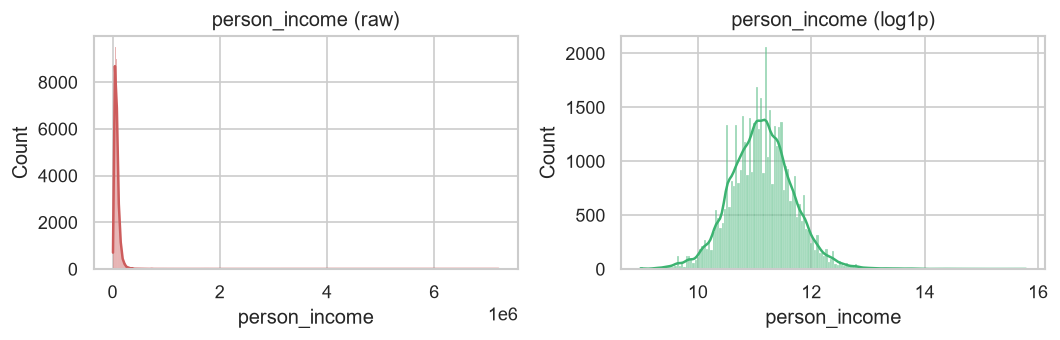

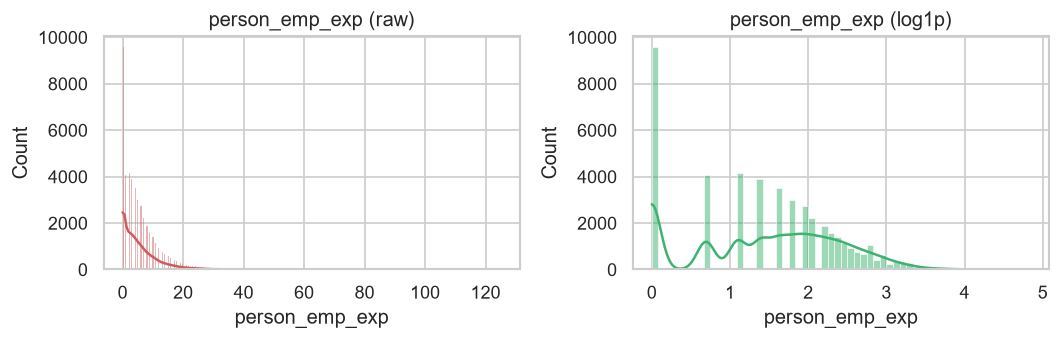

In [3]:
print(f'person_age - max: {df["person_age"].max()}, rows > 80: {(df["person_age"] > 80).sum()}  (capped to 80)')
print(f'person_income - raw skew: {df["person_income"].skew():.2f}  ->  after log1p: {np.log1p(df["person_income"]).skew():.2f}')
print(f'person_emp_exp - raw skew: {df["person_emp_exp"].skew():.2f}  ->  after log1p: {np.log1p(df["person_emp_exp"]).skew():.2f}')

fig, ax = plt.subplots(1, 2, figsize=(9, 3))
sns.histplot(df['person_income'], kde=True, ax=ax[0], color='indianred')
ax[0].set_title('person_income (raw)')
sns.histplot(np.log1p(df['person_income']), kde=True, ax=ax[1], color='mediumseagreen')
ax[1].set_title('person_income (log1p)')
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(1, 2, figsize=(9, 3))
sns.histplot(df['person_emp_exp'], kde=True, ax=ax[0], color='indianred')
ax[0].set_title('person_emp_exp (raw)')
sns.histplot(np.log1p(df['person_emp_exp']), kde=True, ax=ax[1], color='mediumseagreen')
ax[1].set_title('person_emp_exp (log1p)')
plt.tight_layout(); plt.show()

## 3. Train / Test Split (80/20)

Stratified on `loan_status`.   
**k-fold Cross-Validation with k=5**: 5-fold StratifiedKFold runs inside the training set during tuning. Test set is only used during the final evaluation preventing data leakage.

In [4]:
X_train, X_test, y_train, y_test = split_data(df)

for name, y in [('Train', y_train), ('Test', y_test)]:
    print(f'{name:5s}: n={len(y):6,}  |  approved (loan_status=1): {y.mean()*100:.1f}%')

Train: n=36,000  |  approved (loan_status=1): 22.2%
Test : n= 9,000  |  approved (loan_status=1): 22.2%


## 4. Encoding & Scaling

| Feature group | Columns | Strategy |
|---|---|---|
| Numerical | 8 columns | cap age + log skewed features, then StandardScaler (fit on training set only) |
| Ordinal | `person_education` | OrdinalEncoder (High School -> Doctorate = 0-4) |
| Nominal | gender, home_ownership, loan_intent, prev_defaults | OneHotEncoder (`handle_unknown='ignore'`) |

In [10]:
preprocessor = fit_and_save_preprocessor(X_train)   # saves to models/preprocessor.pkl

X_train_enc = transform(preprocessor, X_train)
X_test_enc  = transform(preprocessor, X_test)

feature_names = get_feature_names(preprocessor)

print(f'Encoded shape:\n Train: {X_train_enc.shape}, \n Test: {X_test_enc.shape}')
print(f'Feature names ({len(feature_names)}): \n {feature_names}')

Preprocessor saved to D:\Concordia Courses\Summer 2026\COEN 330\COEN 330 Project\COEN330-Machine-Learning-Project\models\preprocessor.pkl
Encoded shape:
 Train: (36000, 23), 
 Test: (9000, 23)
Feature names (23): 
 ['person_age', 'person_income', 'person_emp_exp', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score', 'person_education', 'person_gender_female', 'person_gender_male', 'person_home_ownership_MORTGAGE', 'person_home_ownership_OTHER', 'person_home_ownership_OWN', 'person_home_ownership_RENT', 'loan_intent_DEBTCONSOLIDATION', 'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE', 'previous_loan_defaults_on_file_No', 'previous_loan_defaults_on_file_Yes']


## 5. Leakage Check

Confirm the target `loan_status` did not leak into the feature matrix.

In [6]:
assert 'loan_status' not in feature_names, 'LEAKAGE: target loan_status leaked into features!'
print('Leakage check passed: target loan_status is not among the features.')

Leakage check passed: target loan_status is not among the features.


## 6. Save Processed Arrays

In [7]:
import json

DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
np.save(DATA_PROCESSED / 'X_train.npy', X_train_enc)
np.save(DATA_PROCESSED / 'X_test.npy',  X_test_enc)
y_train.to_csv(DATA_PROCESSED / 'y_train.csv', index=False)
y_test.to_csv(DATA_PROCESSED / 'y_test.csv',   index=False)
with open(DATA_PROCESSED / 'feature_names.json', 'w') as f:
    json.dump(feature_names, f)

print('Processed data saved to', DATA_PROCESSED)

Processed data saved to D:\Concordia Courses\Summer 2026\COEN 330\COEN 330 Project\COEN330-Machine-Learning-Project\data\processed


## 7. Preprocessing Summary

| Step | Decision | Justification |
|---|---|---|
| Target | `loan_status` (1 = approved, 0 = rejected) | Loan-approval prediction |
| Class balance | approved = ~22% (minority) | Affects metric choice; class weights + threshold tuning for the imbalanced minority |
| Outlier Handling | cap `person_age` at 80 | >80 is implausible age for giving out loans (average life expectancy in Canada = 82.5 years) |
| Skewness | log1p on `person_income` and `person_emp_exp` | Heavy right skew on raw income and employment experience |
| Target Column | `loan_status` excluded from X | It is the prediction target (label `y`), not a feature |
| Encoding | Ordinal for `person_education` | Natural ordering: HS < ... < Doctorate |
| Encoding | OneHotEncoder for other categoricals | No natural ordering; `handle_unknown='ignore'` for demo robustness |
| Scaling | StandardScaler on numerical | Required for distance/margin-based models (SVM, k-NN) |
| Split | 80/20 stratified; 5-fold Cross-Validation inside train set | Test set to be only used for the final evaluation |